In [1]:
from __future__ import annotations

import json
import zipfile
from pathlib import Path
import unicodedata
import numpy as np
import pandas as pd
import holidays
import re
from zoneinfo import ZoneInfo
import duckdb

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score, 
    recall_score
 )
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [2]:
ACCIDENT_YEARS = [2023, 2024, 2025]
ACCIDENTS_DATA_DIR = Path("./data/datasets/sinistros")
ACCIDENTS_CACHE_PATH = Path("./data/datasets/acidentes.csv")
PARQUET_PATH = Path("./data/datasets/dataset_final.parquet")
PARQUET_EXISTS = PARQUET_PATH.exists()

In [3]:
# Funções auxiliares para manipular o dataset

def _load_single_dataset(path: Path, sep: str = ";", encoding: str = "latin1") -> pd.DataFrame:
    """Lê um único CSV de acidentes a partir de um caminho explícito.

    Parameters
    ----------
    path: Path
        Caminho do arquivo CSV a ser lido.
    sep: str
        Separador usado no CSV.
    encoding: str
        Codificação do arquivo original.

    Returns
    -------
    pandas.DataFrame
        Dataframe bruto carregado do arquivo informado.
    """
    return pd.read_csv(path, sep=sep, engine="python", encoding=encoding)


def load_dataset(
    years_or_path: list[int | str] | tuple[int | str, ...] | range | Path | str,
    data_dir: Path | None = None,
    sep: str = ";",
    encoding: str = "latin1",
) -> pd.DataFrame:
    """Carrega um ou mais datasets de acidentes.

    Parameters
    ----------
    years_or_path: list[int | str] | tuple[int | str, ...] | range | Path | str
        Quando `data_dir` é informado, representa os anos a serem lidos em
        ordem crescente. Quando `data_dir` é omitido, mantém o modo legado de
        leitura de um único arquivo por caminho explícito.
    data_dir: Path | None
        Diretório que contém os arquivos `datatran{ano}.csv`. Se `None`, a
        função interpreta `years_or_path` como um caminho de arquivo.
    sep: str
        Separador dos CSVs.
    encoding: str
        Codificação usada na leitura.

    Returns
    -------
    pandas.DataFrame
        Dataframe concatenado do ano mais antigo para o mais recente.

    Raises
    ------
    FileNotFoundError
        Quando um arquivo solicitado não existe.
    ValueError
        Quando a lista de anos fica vazia.
    """
    if data_dir is None:
        if not isinstance(years_or_path, (str, Path)):
            raise TypeError("Quando data_dir nao e informado, years_or_path precisa ser um caminho.")
        return _load_single_dataset(Path(years_or_path), sep=sep, encoding=encoding)

    years = sorted({int(year) for year in years_or_path})
    if not years:
        raise ValueError("Pelo menos um ano deve ser informado para carregar os acidentes.")

    data_dir = Path(data_dir)
    frames: list[pd.DataFrame] = []
    for year in years:
        csv_path = data_dir / f"datatran{year}.csv"
        if not csv_path.exists():
            raise FileNotFoundError(f"Dataset de acidentes nao encontrado: {csv_path}")
        frames.append(_load_single_dataset(csv_path, sep=sep, encoding=encoding))

    return pd.concat(frames, ignore_index=True)


# Tokens que representam valores ausentes
NUMERIC_MISSING_VALUES = [-200, -200.0]

STRING_MISSING_VALUES = [
    "?", " ?", "? ", "NA", "N/A", "na", "n/a", "NaN", "nan", "", " ",
    "unknown", "Unknown", "-200",
]

def make_one_hot_encoder(sparse: bool = True) -> OneHotEncoder:
    """Cria um OneHotEncoder compatível com diferentes versões do scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=sparse)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=sparse)


def split_X_y(df: pd.DataFrame, target: str, extra: list[str]) -> tuple[pd.DataFrame, pd.Series]:
    """Separa variáveis explicativas e alvo de um dataframe.

    Parameters
    ----------
    df: pandas.DataFrame
        Dataframe já preparado para modelagem.
    target: str
        Nome da coluna alvo.
    extra: list[str]
        Colunas auxiliares que devem ser removidas do conjunto de entrada.

    Returns
    -------
    tuple[pandas.DataFrame, pandas.Series]
        `X` com as variáveis explicativas e `y` com o alvo.
    """
    if target not in df.columns:
        raise ValueError(f"Target '{target}' nao esta no dataset.")
    return df.drop(columns=[target] + extra), df[target]


def normalize_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Substitui tokens de missing por NaN, coluna a coluna, respeitando o dtype.

    - Colunas numericas: substitui -200 e -200.0.
    - Colunas de texto: faz strip e substitui tokens como '?', 'unknown', etc.
    Essa abordagem evita erros do pandas 2.x ao misturar int e str no replace().
    """
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].replace(NUMERIC_MISSING_VALUES, np.nan)
        else:
            # Normaliza os tokens de ausente para np.nan antes do imputador,
            # porque pd.NA nesta base gera erro no pipeline com scikit-learn/pandas.
            df[col] = df[col].astype(object)
            df[col] = df[col].apply(lambda v: v.strip() if isinstance(v, str) else v)
            df[col] = df[col].replace(STRING_MISSING_VALUES, np.nan)
    return df


# Pré-Processamento

Os dados de acidentes de trânsito dos datasets da datatran já possuem dados muito interessantes a cerca dos acidentes: números de mortos, feridos, condição da pista, data e hora do acidente, período do dia, dia do acidente.

## Colunas booleanas

Porém, ainda é possível melhorar isso, adicionando colunas booleanas úteis para rápida identificação de informações e melhoria na identificação de certos fatores relacionados a períodos do ano.

Essas colunas são:
* teve_mortos
* teve_feridos_leves
* teve_feridos_graves
* teve_ilesos
* teve_feridos
* teve_ignorados

E também:
* e_feriado: Diz se o acidente aconteceu em um dia de feriado.
* em_feriado_prolongado: Diz se o acidente aconteceu durante um feriado prolongado, como diz a descrição de `build_holiday_flags`.


In [4]:

def build_victim_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Cria as colunas booleanas que indicam presença de vítimas.

    Parameters
    ----------
    df: pandas.DataFrame
        Dataframe bruto dos acidentes, já carregado dos CSVs.

    Returns
    -------
    pandas.DataFrame
        Cópia do dataframe com as colunas `teve_*` adicionadas.
    """
    df = df.copy()
    victim_columns = [
        "mortos",
        "feridos_leves",
        "feridos_graves",
        "ilesos",
        "feridos",
        "ignorados",
    ]
    for column in victim_columns:
        df[f"teve_{column}"] = df[column] > 0
    return df


def normalize_weekday_text(series: pd.Series) -> pd.Series:
    """Normaliza o texto do dia da semana para comparação simples.

    A base usa nomes em português com acentos. Normalizar para ASCII evita
    ter que manter várias grafias em listas de comparação.
    """
    return series.astype(str).map(
        lambda value: "".join(
            character
            for character in unicodedata.normalize("NFKD", value)
            if not unicodedata.combining(character)
        ).lower().strip()
    )


def build_weekend_flag(df: pd.DataFrame) -> pd.Series:
    """Marca sábado e domingo com base na coluna `dia_semana`.

    Returns
    -------
    pandas.Series
        Série booleana com `True` apenas para sábado e domingo.
    """
    normalized_weekday = normalize_weekday_text(df["dia_semana"])
    return normalized_weekday.isin({"sabado", "domingo"})


def build_brazil_holidays(df: pd.DataFrame) -> holidays.Brazil:
    """Cria o calendário de feriados brasileiros cobrindo os anos do dataframe.

    The `holidays` package espera um conjunto de anos. Como o notebook vai
    trabalhar com acidentes de vários anos, essa função infere o intervalo
    necessário diretamente da coluna `data_inversa`.
    """
    accident_years = pd.to_datetime(df["data_inversa"], errors="coerce").dt.year.dropna().astype(int)
    if accident_years.empty:
        return holidays.Brazil(years=[])
    years = sorted(accident_years.unique().tolist())
    return holidays.Brazil(years=years)


def build_holiday_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Cria as colunas `e_feriado` e `em_feriado_prolongado`.

    A lógica usada aqui separa duas ideias diferentes:
    - `e_feriado` marca apenas o dia oficial do feriado.
    - `em_feriado_prolongado` marca o feriado e os dias adjacentes do chamado
      feriado prolongado.

    Para feriados na terça-feira, o período prolongado inclui sábado, domingo,
    segunda e a própria terça. Para feriados na quinta-feira, inclui quinta,
    sexta, sábado e domingo. Para feriados na segunda ou na sexta, a emenda é
    mais curta, cobrindo sábado/domingo + o feriado. Nos demais feriados, a
    coluna de prolongado fica falsa, porque a regra pedida aqui só considera
    esses casos.
    """
    df = df.copy()
    dates = pd.to_datetime(df["data_inversa"], errors="coerce")
    brazil_holidays = build_brazil_holidays(df)
    holiday_dates = {pd.Timestamp(day) for day in brazil_holidays.keys()}
    prolonged_dates: set[pd.Timestamp] = set()

    for holiday_date in holiday_dates:
        if holiday_date.dayofweek == 1:
            # Feriado na terça: emenda com a segunda e o fim de semana anterior.
            prolonged_dates.update(
                {
                    holiday_date - pd.Timedelta(days=3),
                    holiday_date - pd.Timedelta(days=2),
                    holiday_date - pd.Timedelta(days=1),
                    holiday_date,
                }
            )
        elif holiday_date.dayofweek == 3:
            # Feriado na quinta: emenda com a sexta e o fim de semana seguinte.
            prolonged_dates.update(
                {
                    holiday_date,
                    holiday_date + pd.Timedelta(days=1),
                    holiday_date + pd.Timedelta(days=2),
                    holiday_date + pd.Timedelta(days=3),
                }
            )
        elif holiday_date.dayofweek == 0:
            # Feriado na segunda: prolonga com o fim de semana anterior.
            prolonged_dates.update(
                {
                    holiday_date - pd.Timedelta(days=2),
                    holiday_date - pd.Timedelta(days=1),
                    holiday_date,
                }
            )
        elif holiday_date.dayofweek == 4:
            # Feriado na sexta: prolonga com o fim de semana seguinte.
            prolonged_dates.update(
                {
                    holiday_date,
                    holiday_date + pd.Timedelta(days=1),
                    holiday_date + pd.Timedelta(days=2),
                }
            )

    df["e_feriado"] = dates.dt.normalize().isin(holiday_dates)
    df["em_feriado_prolongado"] = dates.dt.normalize().isin(prolonged_dates)
    return df


def preprocess_dataset(
    df: pd.DataFrame,
    cache_path: Path | None = None,
) -> pd.DataFrame:
    """Aplica o pré-processamento final do dataframe de acidentes.

    Parameters
    ----------
    df: pandas.DataFrame
        Dataframe bruto carregado a partir dos CSVs de acidentes.
    cache_path: Path | None
        Caminho opcional para persistir o dataframe final. Quando informado, a
        função salva a saída em cache após o processamento.

    Returns
    -------
    pandas.DataFrame
        Dataframe final com as flags booleanas e temporais adicionadas.
    """
    if cache_path is not None and cache_path.exists():
        print(f"Cache hit: {cache_path}")
        return pd.read_csv(cache_path)

    processed_df = build_victim_flags(df)
    processed_df["e_fim_de_semana"] = build_weekend_flag(processed_df)
    processed_df = build_holiday_flags(processed_df)

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        processed_df.to_csv(cache_path, index=False, encoding="utf-8")

    return processed_df


def load_or_preprocess_dataset(
    years_or_path: list[int | str] | tuple[int | str, ...] | range | Path | str,
    data_dir: Path | None = None,
    cache_path: Path | None = None,
    sep: str = ";",
    encoding: str = "latin1",
) -> pd.DataFrame:
    """Carrega do cache ou executa o fluxo completo de carregamento e pré-processamento.

    Essa função é usada no fluxo principal do notebook para evitar que os CSVs
    brutos sejam lidos quando `acidentes.csv` já existe.
    """
    if cache_path is not None and cache_path.exists():
        print(f"Cache hit: {cache_path}")
        return pd.read_csv(cache_path)

    raw_df = load_dataset(years_or_path, data_dir=data_dir, sep=sep, encoding=encoding)
    return preprocess_dataset(raw_df, cache_path=cache_path)



In [5]:
if not PARQUET_EXISTS:
    df = load_or_preprocess_dataset(
        ACCIDENT_YEARS,
        data_dir=ACCIDENTS_DATA_DIR,
        cache_path=ACCIDENTS_CACHE_PATH,    
    )
    df_acidentes = df

    df.head()

In [6]:
if not PARQUET_EXISTS:
    boolean_cols = df.select_dtypes(include="bool").columns.tolist()

    bool_counts = pd.DataFrame(
        {
            "True": df[boolean_cols].sum(),
            "False": (~df[boolean_cols]).sum(),
        }
    ).astype(int)

    display(bool_counts)

    categorical_columns = [
        "tipo_acidente",
        "classificacao_acidente",
        "fase_dia",
        "causa_acidente",
        "condicao_metereologica",
        "tipo_pista",
        "tracado_via",
        "regional"
    ]

    unique_values = {
        column: sorted(df[column].dropna().unique().tolist())
        for column in categorical_columns
        if column in df.columns
    }

    unique_values_df = pd.DataFrame(
        {
            "coluna": list(unique_values.keys()),
            "valores_unicos": list(unique_values.values()),
        }
     )

    display(unique_values_df)

# Integração com fontes externas

## Inmet

A primeira fonte de integração externa a ser utilizada será o INMET, que fornecerá dados acerca das condições climáticas no momento do acidente.

Os datasets do INMET, tem algumas peculiaridades que dificultam sua integração:

**Nomenclatura dos arquivos**

Nos CSVs do INMET estão os nomes das cidades onde as estações se localizam. Muitas cidades contém espaços em seus nomes, o que acaba gerando alguns erros nas leituras de CSVs, o que torna necessário normalizar o nome desses arquivos.

**Cabeçalho nos CSVs:**

```txt
REGIAO:;CO
UF:;DF
ESTACAO:;BRASILIA
CODIGO (WMO):;A001
LATITUDE:;-15,78944444
LONGITUDE:;-47,92583332
ALTITUDE:;1160,96
DATA DE FUNDACAO:;07/05/00
<Colunas>
```

Todo csv do INMET apresenta seus dados da estação nas 8 primeiras linhas do dataset, então, não se pode simplesmente só ler o arquivo e extrair as informações úteis. A partir da 9ª linha, começam os dados históricos da estação naquele no ano em escolhido.

**Grande quantidade de arquivos**

Para cada estação existe um arquivo, totalizando mais de quinhentos arquivos. Mesmo com um grande volume de acidentes, eles ocorreram em rodovias federais, então, é altamente improvável que todas as estações sejam usadas para complementar os dados de acidentes.


---

Para resolver esses problemas, é necessário realizar alguns pré-processamentos:
1. Extrair todos os dados das estações em um arquivo separado
2. Sanitizar os nomes dos arquivos, removendo espaços.
3. Com as estações, identificar quais são efetivamente viáveis para complementar o dataset de acidentes, descartando as que forem desnecessárias.
4. Das estações úteis, condensar todo o histórico dessas estações em um único CSV.
5. O objetivo é transformar todos os dados do INMET em dois CSVs: estações e histórico estações.



In [7]:
INMET_YEARS = ACCIDENT_YEARS 
INMET_RAW_ROOT = Path("./data/datasets/inmet_raw")
INMET_PROCESSED_ROOT = Path("./data/datasets/inmet_processed")
INMET_FILENAME_RE = re.compile(
    r"^INMET_(?P<regiao>[^_]+)_(?P<uf>[^_]+)_(?P<estacao_id>[^_]+)_(?P<cidade>.+)_(?P<periodo>\d{2}-\d{2}-\d{4}_A_\d{2}-\d{2}-\d{4})\.CSV$",
    re.IGNORECASE,
)

In [8]:
def normalize_inmet_token(value: str) -> str:
    """Normaliza um pedaço do nome da estação para poder usar como parte de arquivo.

    A função pega somente o texto da cidade ou de outro fragmento humano e faz uma
    transformação mecânica: remove espaços em branco repetidos e troca cada sequência
    de espaços por `-`. Ela não muda maiúsculas/minúsculas, não remove acentos e não
    tenta resolver nenhum outro caractere especial.

    Exemplo
    -------
    `SÃO JOÃO DA BARRA` -> `SÃO-JOÃO-DA-BARRA`
    """
    return re.sub(r"\s+", "-", value.strip())


def parse_inmet_filename(filename: str) -> dict[str, str]:
    """Lê o nome bruto do CSV do INMET e extrai os campos codificados nele.

    O padrão esperado é algo como::

        INMET_CO_DF_A001_BRASILIA_01-01-2025_A_31-12-2025.CSV

    A função valida se o nome bate com a regex definida para o projeto e, se bater,
    separa o nome em cinco pedaços úteis: região, UF, código da estação, cidade e
    período. A cidade passa pela normalização de hífens para virar uma chave segura
    de arquivo. Os demais campos são devolvidos em maiúsculas porque esse é o formato
    canônico usado no pipeline.

    Returns
    -------
    dict[str, str]
        Dicionário com `regiao`, `uf`, `estacao_id`, `cidade` e `periodo`.
    """
    match = INMET_FILENAME_RE.match(filename)
    if match is None:
        raise ValueError(f"Nome de arquivo INMET fora do padrao esperado: {filename}")

    info = match.groupdict()
    return {
        "regiao": info["regiao"].upper(),
        "uf": info["uf"].upper(),
        "estacao_id": info["estacao_id"].upper(),
        "cidade": normalize_inmet_token(info["cidade"]),
        "periodo": info["periodo"],
    }


def build_inmet_output_stem(filename: str) -> str:
    """Monta o nome-base dos CSVs derivados a partir do nome bruto do INMET.

    A função primeiro chama `parse_inmet_filename()` para decompor o nome original e
    depois recompõe um prefixo padronizado no formato::

        inmet_<regiao>_<uf>_<estacao_id>_<cidade>_<periodo>_dados

    Esse prefixo é usado tanto para o CSV de histórico quanto para o arquivo de
    metadados da estação. O objetivo é garantir que um arquivo bruto sempre gere os
    mesmos nomes de saída, independentemente de onde o pipeline seja executado.
    """
    info = parse_inmet_filename(filename)
    return (
        f"inmet_{info['regiao']}_{info['uf']}_{info['estacao_id']}_"
        f"{info['cidade']}_{info['periodo']}_dados"
    )


def load_inmet_station_metadata(path: Path) -> pd.DataFrame:
    """Lê as linhas de metadados no topo de um CSV bruto do INMET."""
    metadata = pd.read_csv(
        path,
        sep=";",
        encoding="latin1",
        nrows=8,
        header=None,
        names=["coluna", "valor"],
        engine="python",
    )
    metadata["coluna"] = metadata["coluna"].astype(str).str.replace(":", "", regex=False).str.strip()
    metadata["valor"] = metadata["valor"].astype(str).str.strip()
    return metadata


def load_inmet_data(path: Path) -> pd.DataFrame:
    """Lê o histórico de medições de um arquivo bruto do INMET."""
    df = pd.read_csv(path, sep=";", encoding="latin1", skiprows=8, engine="python")
    df = df.dropna(axis=1, how="all")
    df.columns = [str(column).strip() for column in df.columns]
    return df


def _normalize_inmet_column_name(value: object) -> str:
    """Normaliza nomes de colunas do INMET para facilitar comparações estruturais."""
    normalized = unicodedata.normalize("NFKD", str(value))
    normalized = "".join(character for character in normalized if not unicodedata.combining(character))
    normalized = normalized.lower().strip()
    return re.sub(r"[^a-z0-9]+", "_", normalized).strip("_")


def _summarize_inmet_precipitation(raw_data_df: pd.DataFrame) -> tuple[str | None, int, int]:
    """Identifica a coluna de precipitação e conta linhas sem medição válida."""
    precipitation_column = None
    for column in raw_data_df.columns:
        normalized_column = _normalize_inmet_column_name(column)
        if (
            normalized_column.startswith("precip")
            and "total" in normalized_column
            and "horario" in normalized_column
            and "mm" in normalized_column
        ):
            precipitation_column = column
            break

    total_rows = len(raw_data_df)
    if precipitation_column is None or total_rows == 0:
        return precipitation_column, total_rows, total_rows

    precipitation_series = raw_data_df[precipitation_column].apply(
        lambda value: value.strip() if isinstance(value, str) else value
    )
    precipitation_series = precipitation_series.replace(NUMERIC_MISSING_VALUES, np.nan)
    precipitation_series = precipitation_series.replace(STRING_MISSING_VALUES, np.nan)

    missing_rows = int(precipitation_series.isna().sum())
    return precipitation_column, missing_rows, total_rows


def preprocess_inmet_file(path: Path, output_dir: Path) -> tuple[dict[str, str], bool]:
    """Processa um arquivo bruto do INMET e indica se ele deve ser ignorado.

    O retorno é uma dupla ``(resultado, skip)``. O primeiro item preserva a estrutura
    atual do resumo do arquivo processado. O segundo item sinaliza se o arquivo deve
    ser descartado porque não possui coluna de precipitação útil ou porque mais de
    80% das linhas dessa coluna estão sem medição.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    output_stem = build_inmet_output_stem(path.name)
    metadata_path = output_dir / f"{output_stem}_station_metadata.csv"
    data_path = output_dir / f"{output_stem}.csv"

    raw_data_df = pd.read_csv(path, sep=";", encoding="latin1", skiprows=8, engine="python")
    precipitation_column, missing_rows, total_rows = _summarize_inmet_precipitation(raw_data_df)
    missing_ratio = (missing_rows / total_rows) if total_rows else 1.0
    skip = precipitation_column is None or missing_ratio > 0.8

    if skip:
        if precipitation_column is None:
            reason = "sem coluna de precipitacao"
        else:
            reason = f"{missing_rows}/{total_rows} linhas sem precipitacao ({missing_ratio:.1%})"
        print(f"[AVISO] Pulando {path.name}: {reason}")
        return (
            {
                "input_file": path.name,
                "metadata_path": str(metadata_path),
                "data_path": str(data_path),
            },
            True,
        )

    metadata_df = load_inmet_station_metadata(path)
    data_df = load_inmet_data(path)

    metadata_df.to_csv(metadata_path, index=False)
    data_df.to_csv(data_path, index=False)

    return (
        {
            "input_file": path.name,
            "metadata_path": str(metadata_path),
            "data_path": str(data_path),
        },
        False,
    )


def load_cached_inmet_directory_results(output_dir: Path, year_label: str) -> list[dict[str, str]]:
    """Reconstrói o resumo de uma pasta de INMET já processada, reaplicando o filtro de precipitação."""
    cached_results: list[dict[str, str]] = []
    metadata_files = sorted(output_dir.glob("*_station_metadata.csv"))
    skipped_files = 0

    for metadata_path in metadata_files:
        data_path = output_dir / metadata_path.name.replace("_station_metadata.csv", ".csv")
        if not data_path.exists():
            continue

        cached_data_df = pd.read_csv(data_path)
        precipitation_column, missing_rows, total_rows = _summarize_inmet_precipitation(cached_data_df)
        missing_ratio = (missing_rows / total_rows) if total_rows else 1.0
        if precipitation_column is None or missing_ratio > 0.8:
            skipped_files += 1
            if precipitation_column is None:
                reason = "sem coluna de precipitacao"
            else:
                reason = f"{missing_rows}/{total_rows} linhas sem precipitacao ({missing_ratio:.1%})"
            print(f"[AVISO] Pulando cache {data_path.name}: {reason}")
            continue

        cached_results.append(
            {
                "input_file": data_path.name,
                "metadata_path": str(metadata_path),
                "data_path": str(data_path),
                "year": year_label,
            }
        )

    print(f"Cache hit: {output_dir} | {len(cached_results)} arquivos reutilizados | {skipped_files} pulados")
    return cached_results


def preprocess_inmet_directory(year: int | str, source_root: Path, output_root: Path) -> list[dict[str, str]]:
    """Processa todos os CSVs de INMET de um ano, com cache por diretório."""
    year_label = str(year)
    source_dir = source_root / year_label
    output_dir = output_root / year_label

    if output_dir.exists():
        return load_cached_inmet_directory_results(output_dir, year_label)

    if not source_dir.exists():
        raise FileNotFoundError(f"Diretorio INMET nao encontrado: {source_dir}")

    csv_files = sorted(
        path for path in source_dir.iterdir()
        if path.is_file() and path.suffix.lower() == ".csv"
    )

    results: list[dict[str, str]] = []
    skipped_files = 0
    for path in csv_files:
        try:
            item, skip = preprocess_inmet_file(path, output_dir)
            if skip:
                skipped_files += 1
                continue
            item["year"] = year_label
            results.append(item)
        except Exception as exc:
            print(f"[ERRO] {path.name}: {exc}")

    print(
        f"Processados {len(results)} de {len(csv_files)} arquivos INMET em {output_dir} | "
        f"pulados {skipped_files}"
    )
    return results


if not PARQUET_EXISTS:
    inmet_results = []
    for year in INMET_YEARS:
        try:
            inmet_results.extend(preprocess_inmet_directory(year, INMET_RAW_ROOT, INMET_PROCESSED_ROOT))
        except Exception as exc:
            print(f"[ERRO] ano={year}: {exc}")

    inmet_results[:3]

In [9]:
INMET_PROCESSED_ROOT = Path("./data/datasets/inmet_processed")
INMET_AGGREGATED_ROOT = Path("./data/datasets/inmet_aggregated")
INMET_HISTORICO_PATH = INMET_AGGREGATED_ROOT / "inmet_historico.parquet"
ESTACOES_BASE_PATH = INMET_AGGREGATED_ROOT / "estacoes.csv"
ESTACOES_FINAIS_PATH = INMET_AGGREGATED_ROOT / "estacoes_finais.csv"
SINISTRO_ESTACAO_MAIS_PROXIMA_PATH = INMET_AGGREGATED_ROOT / "sinistro_estacao_mais_proxima.csv"
ACCIDENTS_CACHE_PATH = Path("./data/datasets/acidentes.csv")
BRASILIA_TZ = ZoneInfo("America/Sao_Paulo")

METADATA_KEY_ALIASES = {
    "regiao": "regiao",
    "uf": "uf",
    "estacao": "estacao",
    "codigo_wmo": "wmo",
    "wmo": "wmo",
    "latitude": "latitude",
    "longitude": "longitude",
    "altitude": "altitude",
    "data_de_fundacao": "data_de_fundacao",
}

EXPECTED_STATION_COLUMNS = [
    "wmo",
    "regiao",
    "uf",
    "estacao",
    "latitude",
    "longitude",
    "altitude",
    "data_de_fundacao",
    "source_file",
]

EXPECTED_MAPPING_COLUMNS = ["id", "wmo", "distancia_km"]


def slugify_text(value: object) -> str:
    """Normaliza texto para lower_snake_case ASCII."""
    text = unicodedata.normalize("NFKD", str(value))
    text = text.encode("ascii", "ignore").decode("ascii")
    text = text.lower().strip()
    return re.sub(r"[^a-z0-9]+", "_", text).strip("_")


def normalize_dataframe_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Padroniza os nomes das colunas para lower_snake_case ASCII."""
    kept_columns: list[str] = []
    normalized_columns: list[str] = []
    counts: dict[str, int] = {}

    for column in df.columns:
        normalized = slugify_text(column)
        if not normalized or normalized.startswith("unnamed"):
            continue

        count = counts.get(normalized, 0)
        counts[normalized] = count + 1
        kept_columns.append(column)
        normalized_columns.append(normalized if count == 0 else f"{normalized}_{count + 1}")

    cleaned_df = df.loc[:, kept_columns].copy()
    cleaned_df.columns = normalized_columns
    return cleaned_df


def normalize_station_value(value: object) -> str | None:
    """Remove espaços e trata strings vazias como ausentes."""
    if value is None or pd.isna(value):
        return None

    text = str(value).strip()
    if not text or text.lower() in {"nan", "none"}:
        return None
    return text


def clean_station_catalog(df: pd.DataFrame) -> pd.DataFrame:
    """Limpa o catálogo sem alterar o schema esperado."""
    cleaned_df = normalize_dataframe_columns(df)
    for column in cleaned_df.columns:
        cleaned_df[column] = cleaned_df[column].map(normalize_station_value)
    return cleaned_df


def load_station_metadata_row(metadata_path: Path) -> dict[str, str | None]:
    """Lê um arquivo de metadados do INMET e extrai os campos conhecidos."""
    metadata_df = pd.read_csv(metadata_path, dtype=str)

    if not {"coluna", "valor"}.issubset(metadata_df.columns):
        raise ValueError(f"Metadata invalido em {metadata_path.name}")

    metadata_lookup: dict[str, str | None] = {}
    for _, row in metadata_df[["coluna", "valor"]].iterrows():
        raw_key = slugify_text(row["coluna"])
        mapped_key = METADATA_KEY_ALIASES.get(raw_key)
        if mapped_key is not None:
            metadata_lookup[mapped_key] = normalize_station_value(row["valor"])

    wmo = metadata_lookup.get("wmo")
    if not wmo:
        raise ValueError(f"Nao foi possivel extrair o WMO de {metadata_path.name}")

    return {
        "wmo": wmo,
        "regiao": metadata_lookup.get("regiao"),
        "uf": metadata_lookup.get("uf"),
        "estacao": metadata_lookup.get("estacao"),
        "latitude": metadata_lookup.get("latitude"),
        "longitude": metadata_lookup.get("longitude"),
        "altitude": metadata_lookup.get("altitude"),
        "data_de_fundacao": metadata_lookup.get("data_de_fundacao"),
        "source_file": metadata_path.name.replace("_station_metadata.csv", ".csv"),
    }


def build_station_catalog_from_processed(years: list[int | str]) -> pd.DataFrame:
    """Monta o catálogo base a partir dos metadados já processados."""
    station_rows: list[dict[str, str | None]] = []
    seen_wmo: set[str] = set()

    for year in years:
        year_dir = INMET_PROCESSED_ROOT / str(year)
        if not year_dir.exists():
            print(f"[AVISO] Diretorio ausente, ignorando: {year_dir}")
            continue

        metadata_files = sorted(year_dir.glob("*_station_metadata.csv"))
        if not metadata_files:
            print(f"[AVISO] Nenhum metadata encontrado em: {year_dir}")
            continue

        for metadata_path in metadata_files:
            try:
                station_row = load_station_metadata_row(metadata_path)
            except Exception as exc:
                print(f"[ERRO] {metadata_path.name}: {exc}")
                continue

            wmo = station_row["wmo"]
            if wmo in seen_wmo:
                continue

            station_rows.append(station_row)
            seen_wmo.add(wmo)

    if not station_rows:
        raise RuntimeError("Nenhum arquivo INMET valido foi encontrado para consolidacao das estacoes.")

    station_df = pd.DataFrame(station_rows, columns=EXPECTED_STATION_COLUMNS)
    return clean_station_catalog(station_df)


def load_station_catalog() -> pd.DataFrame:
    """Carrega o catálogo base ou o recompõe por processamento local."""
    if ESTACOES_BASE_PATH.exists():
        print(f"Cache hit: {ESTACOES_BASE_PATH}")
        return clean_station_catalog(pd.read_csv(ESTACOES_BASE_PATH, dtype=str))[EXPECTED_STATION_COLUMNS]

    station_df = build_station_catalog_from_processed(INMET_YEARS)
    INMET_AGGREGATED_ROOT.mkdir(parents=True, exist_ok=True)
    station_df.to_csv(ESTACOES_BASE_PATH, index=False, encoding="utf-8")
    return station_df


def load_inmet_historico_cache() -> pd.DataFrame | None:
    """Carrega o histórico em Parquet."""
    if not INMET_HISTORICO_PATH.exists():
        return None

    print(f"Cache hit: {INMET_HISTORICO_PATH}")
    return pd.read_parquet(INMET_HISTORICO_PATH, engine="pyarrow")


def load_accident_source() -> pd.DataFrame:
    """Carrega os sinistros usados para escolher as estações mais próximas.

    Prioriza o dataframe já carregado no notebook e, se ele não estiver disponível,
    recai para o CSV pré-processado `data/datasets/acidentes.csv`.
    """
    existing_df = globals().get("df")
    if isinstance(existing_df, pd.DataFrame) and {"latitude", "longitude"}.issubset(existing_df.columns):
        return existing_df.copy()

    if not ACCIDENTS_CACHE_PATH.exists():
        raise FileNotFoundError(f"Arquivo de acidentes nao encontrado: {ACCIDENTS_CACHE_PATH}")

    return pd.read_csv(ACCIDENTS_CACHE_PATH, dtype=str)


def to_numeric_coordinate(series: pd.Series) -> pd.Series:
    """Converte coordenadas com vírgula decimal para número."""
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce",
    )


def haversine_distances_km(
    latitude: float,
    longitude: float,
    station_latitudes: np.ndarray,
    station_longitudes: np.ndarray,
) -> np.ndarray:
    """Calcula distâncias Haversine em quilômetros para várias estações."""
    earth_radius_km = 6371.0088
    lat1 = np.radians(latitude)
    lon1 = np.radians(longitude)
    lat2 = np.radians(station_latitudes.astype(float))
    lon2 = np.radians(station_longitudes.astype(float))
    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1
    a = np.sin(delta_lat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2.0) ** 2
    return 2.0 * earth_radius_km * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))


def build_accident_station_mapping(station_catalog: pd.DataFrame, accident_df: pd.DataFrame) -> pd.DataFrame:
    """Relaciona cada sinistro válido com a estação mais próxima."""
    stations_with_coordinates = station_catalog.copy()
    stations_with_coordinates["latitude_num"] = to_numeric_coordinate(stations_with_coordinates["latitude"])
    stations_with_coordinates["longitude_num"] = to_numeric_coordinate(stations_with_coordinates["longitude"])
    stations_with_coordinates = stations_with_coordinates.dropna(subset=["latitude_num", "longitude_num"]).copy()

    if stations_with_coordinates.empty:
        raise RuntimeError("Nao foi possivel encontrar estações com coordenadas validas.")

    accidents_with_coordinates = accident_df.copy()
    accidents_with_coordinates["latitude_num"] = to_numeric_coordinate(accidents_with_coordinates["latitude"])
    accidents_with_coordinates["longitude_num"] = to_numeric_coordinate(accidents_with_coordinates["longitude"])
    accidents_with_coordinates = accidents_with_coordinates.dropna(subset=["latitude_num", "longitude_num"]).copy()

    mapping_rows: list[dict[str, object]] = []
    station_latitudes = stations_with_coordinates["latitude_num"].to_numpy(dtype=float)
    station_longitudes = stations_with_coordinates["longitude_num"].to_numpy(dtype=float)

    # Mantém um relacionamento persistido para evitar recalcular as distâncias em execuções futuras.
    for accident in accidents_with_coordinates.itertuples(index=False):
        accident_id = normalize_station_value(getattr(accident, "id", None))
        if not accident_id:
            continue

        distances = haversine_distances_km(
            float(accident.latitude_num),
            float(accident.longitude_num),
            station_latitudes,
            station_longitudes,
        )
        nearest_index = int(np.argmin(distances))
        nearest_station = stations_with_coordinates.iloc[nearest_index]
        mapping_rows.append(
            {
                "id": accident_id,
                "wmo": str(nearest_station["wmo"]),
                "distancia_km": float(distances[nearest_index]),
            }
        )

    mapping_df = pd.DataFrame(mapping_rows, columns=EXPECTED_MAPPING_COLUMNS)
    if not mapping_df.empty:
        print(
            f"Sinistros válidos: {len(mapping_df)} | "
            f"estações distintas: {mapping_df['wmo'].nunique()} | "
            f"distancia media: {mapping_df['distancia_km'].mean():.2f} km"
        )
    else:
        print("Nenhum sinistro válido com coordenadas foi encontrado.")
    return mapping_df


def load_or_build_accident_station_mapping(station_catalog: pd.DataFrame, accident_df: pd.DataFrame) -> pd.DataFrame:
    """Carrega sinistro_estacao_mais_proxima.csv ou gera o relacionamento do zero."""
    if SINISTRO_ESTACAO_MAIS_PROXIMA_PATH.exists():
        print(f"Cache hit: {SINISTRO_ESTACAO_MAIS_PROXIMA_PATH}")
        mapping_df = pd.read_csv(SINISTRO_ESTACAO_MAIS_PROXIMA_PATH, dtype={"id": str, "wmo": str})
        mapping_df = mapping_df.rename(columns=slugify_text)
        mapping_df = mapping_df[[column for column in EXPECTED_MAPPING_COLUMNS if column in mapping_df.columns]]
        if "distancia_km" in mapping_df.columns:
            mapping_df["distancia_km"] = pd.to_numeric(mapping_df["distancia_km"], errors="coerce")
        return mapping_df

    mapping_df = build_accident_station_mapping(station_catalog, accident_df)
    INMET_AGGREGATED_ROOT.mkdir(parents=True, exist_ok=True)
    mapping_df.to_csv(SINISTRO_ESTACAO_MAIS_PROXIMA_PATH, index=False, encoding="utf-8")
    return mapping_df


def load_or_build_final_stations(station_catalog: pd.DataFrame, accident_station_mapping: pd.DataFrame) -> pd.DataFrame:
    """Carrega estacoes_finais.csv ou recalcula a seleção a partir do relacionamento persistido."""
    if ESTACOES_FINAIS_PATH.exists():
        print(f"Cache hit: {ESTACOES_FINAIS_PATH}")
        return clean_station_catalog(pd.read_csv(ESTACOES_FINAIS_PATH, dtype=str))[EXPECTED_STATION_COLUMNS]

    selected_wmos = sorted(
        accident_station_mapping["wmo"].dropna().astype(str).unique().tolist()
    )
    final_stations = station_catalog.loc[station_catalog["wmo"].isin(selected_wmos)].copy()
    final_stations = final_stations[EXPECTED_STATION_COLUMNS]
    final_stations.to_csv(ESTACOES_FINAIS_PATH, index=False, encoding="utf-8")
    return final_stations


def build_processed_file_index() -> dict[str, Path]:
    """Indexa os CSVs processados por nome do arquivo para leitura rápida."""
    file_index: dict[str, Path] = {}
    for data_path in INMET_PROCESSED_ROOT.rglob("*_dados.csv"):
        file_index[data_path.name] = data_path
    return file_index


def parse_and_convert_station_history(data_path: Path, wmo: str) -> pd.DataFrame:
    """Normaliza um CSV bruto de estação para o formato final do histórico."""
    raw_df = pd.read_csv(data_path, encoding="latin1")
    raw_df = normalize_dataframe_columns(raw_df)

    if not {"data", "hora_utc"}.issubset(raw_df.columns):
        raise ValueError(f"Colunas de data ausentes em {data_path.name}")

    timestamps_utc = pd.to_datetime(
        raw_df["data"].astype(str).str.strip() + " " + raw_df["hora_utc"].astype(str).str.strip(),
        format="%Y/%m/%d %H%M UTC",
        errors="coerce",
        utc=True,
    )

    converted_df = raw_df.drop(columns=["data", "hora_utc"], errors="ignore").copy()
    converted_df.insert(0, "wmo", wmo)
    converted_df.insert(
        1,
        "data_hora",
        timestamps_utc.dt.tz_convert(BRASILIA_TZ).dt.strftime("%Y-%m-%d %H:%M:%S"),
    )
    converted_df = converted_df.dropna(subset=["data_hora"]).copy()

    for column in converted_df.columns:
        if column in {"wmo", "data_hora"}:
            continue
        converted_df[column] = pd.to_numeric(
            converted_df[column].astype(str).str.replace(",", ".", regex=False).str.strip(),
            errors="coerce",
        )

    ordered_columns = ["wmo", "data_hora"] + [column for column in converted_df.columns if column not in {"wmo", "data_hora"}]
    return converted_df.loc[:, ordered_columns]


def build_historico_from_catalog(selected_catalog: pd.DataFrame) -> pd.DataFrame:
    """Consolida apenas os arquivos das estações selecionadas."""
    if selected_catalog.empty:
        return pd.DataFrame(columns=["wmo", "data_hora"])

    file_index = build_processed_file_index()
    history_chunks: list[pd.DataFrame] = []
    missing_files: list[str] = []

    for station in selected_catalog.itertuples(index=False):
        source_file = normalize_station_value(getattr(station, "source_file", None))
        if not source_file:
            continue

        data_path = file_index.get(source_file)
        if data_path is None:
            missing_files.append(source_file)
            continue

        station_history = parse_and_convert_station_history(data_path, str(station.wmo))
        if not station_history.empty:
            history_chunks.append(station_history)

    if missing_files:
        print("[AVISO] Arquivos de histórico nao encontrados:")
        for missing_file in sorted(set(missing_files)):
            print(f"  - {missing_file}")

    if not history_chunks:
        return pd.DataFrame(columns=["wmo", "data_hora"])

    historico_df = pd.concat(history_chunks, ignore_index=True)
    historico_df = historico_df.sort_values(["wmo", "data_hora"], kind="stable").reset_index(drop=True)
    ordered_columns = ["wmo", "data_hora"] + [column for column in historico_df.columns if column not in {"wmo", "data_hora"}]
    return historico_df.loc[:, ordered_columns]


def load_or_build_historico(selected_catalog: pd.DataFrame) -> pd.DataFrame:
    """Carrega inmet_historico.parquet ou gera a consolidação final do zero."""
    cached_df = load_inmet_historico_cache()
    if cached_df is not None:
        return cached_df

    historico_df = build_historico_from_catalog(selected_catalog)
    historico_df.to_parquet(INMET_HISTORICO_PATH, index=False, compression="snappy", engine="pyarrow")
    return historico_df


if not PARQUET_EXISTS:
    INMET_AGGREGATED_ROOT.mkdir(parents=True, exist_ok=True)
    station_catalog = load_station_catalog()
    accident_df = load_accident_source()
    accident_station_mapping = load_or_build_accident_station_mapping(station_catalog, accident_df)
    final_station_catalog = load_or_build_final_stations(station_catalog, accident_station_mapping)
    historico_df = load_or_build_historico(final_station_catalog)

In [10]:
if not PARQUET_EXISTS:
    print(f"Arquivo de estacoes finais: {ESTACOES_FINAIS_PATH}")
    print(f"Estacoes base: {len(station_catalog)}")
    print(f"Estacoes finais: {len(final_station_catalog)}")
    final_station_catalog.head()

In [11]:
if not PARQUET_EXISTS:
    print(f"Arquivo de relacionamento: {SINISTRO_ESTACAO_MAIS_PROXIMA_PATH}")
    print(f"Relacionamento sinistro-estacao: {len(accident_station_mapping)}")
    accident_station_mapping.head()

In [12]:
if not PARQUET_EXISTS:
    print(f"Arquivo de historico: {INMET_HISTORICO_PATH}")
    print(f"Historico INMET: {len(historico_df)}")
    historico_df.head()

## Acrestando informação de precipitação

In [13]:
ACIDENTES_FINAL_PATH = ACCIDENTS_CACHE_PATH.with_name("acidentes_final.csv")


def _resolve_precipitation_column(df: pd.DataFrame) -> str:
    """Localiza, no histórico do INMET, a coluna com a precipitação horária total."""
    normalized_to_original = {slugify_text(column): column for column in df.columns}
    for normalized, original in normalized_to_original.items():
        if (
            normalized.startswith("precip")
            and "total" in normalized
            and "horario" in normalized
            and "mm" in normalized
        ):
            return original
    raise ValueError(
        "Nao foi possivel identificar a coluna de precipitacao no historico_df."
    )


def _floor_to_hour(series: pd.Series) -> pd.Series:
    """Converte uma série de datas e horas para o início da respectiva hora."""
    return pd.to_datetime(series, errors="coerce").dt.floor("h")


def _normalize_coordinate_text(value: object) -> str | None:
    """Padroniza coordenadas como texto com vírgula decimal."""
    if value is None or pd.isna(value):
        return None

    text = str(value).strip()
    if not text:
        return None

    return text.replace(".", ",")


def _load_accidents_source() -> pd.DataFrame:
    """Carrega o CSV de acidentes já processado e usado como base do enriquecimento."""
    if not ACCIDENTS_CACHE_PATH.exists():
        raise FileNotFoundError(
            f"Arquivo de acidentes nao encontrado: {ACCIDENTS_CACHE_PATH}"
        )
    return pd.read_csv(ACCIDENTS_CACHE_PATH)


def build_accidentes_final() -> pd.DataFrame:
    """Gera o dataset final de acidentes com estação mais próxima e precipitação do momento.

    A função preserva todas as linhas de `acidentes.csv`, associa cada acidente à
    estação mais próxima via `accident_station_mapping` e, em seguida, busca no
    `historico_df` a precipitação da mesma hora do acidente. Quando não existir
    informação de precipitação para o horário correspondente, o valor é preenchido
    com `0`. O resultado é salvo em cache em `acidentes_final.csv`.
    """
    if ACIDENTES_FINAL_PATH.exists():
        print(f"Cache hit: {ACIDENTES_FINAL_PATH}")
        cached_df = pd.read_csv(ACIDENTES_FINAL_PATH)
        if "momento_acidente" in cached_df.columns:
            cached_df = cached_df.drop(columns=["momento_acidente"])
        for column in ["latitude", "longitude"]:
            if column in cached_df.columns:
                cached_df[column] = cached_df[column].map(_normalize_coordinate_text)
        if "precimitacao_momento" in cached_df.columns:
            cached_df["precimitacao_momento"] = pd.to_numeric(
                cached_df["precimitacao_momento"], errors="coerce"
            ).fillna(0)
        cached_df.to_csv(ACIDENTES_FINAL_PATH, index=False, encoding="utf-8")
        return cached_df

    accidents_source = _load_accidents_source().copy()
    for column in ["latitude", "longitude"]:
        if column in accidents_source.columns:
            accidents_source[column] = accidents_source[column].map(
                _normalize_coordinate_text
            )

    station_mapping = globals().get("accident_station_mapping")
    if not isinstance(station_mapping, pd.DataFrame):
        if not SINISTRO_ESTACAO_MAIS_PROXIMA_PATH.exists():
            raise FileNotFoundError(
                f"Arquivo de relacionamento nao encontrado: {SINISTRO_ESTACAO_MAIS_PROXIMA_PATH}"
            )
        station_mapping = pd.read_csv(SINISTRO_ESTACAO_MAIS_PROXIMA_PATH)

    weather_history = globals().get("historico_df")
    if not isinstance(weather_history, pd.DataFrame):
        weather_history = load_inmet_historico_cache()
        if weather_history is None:
            raise FileNotFoundError(
                f"Arquivo de historico nao encontrado: {INMET_HISTORICO_PATH}"
            )

    required_accident_columns = {"id", "data_inversa", "horario"}
    missing_accident_columns = required_accident_columns.difference(
        accidents_source.columns
    )
    if missing_accident_columns:
        raise ValueError(
            f"Colunas ausentes em acidentes.csv: {sorted(missing_accident_columns)}"
        )

    required_mapping_columns = {"id", "wmo"}
    missing_mapping_columns = required_mapping_columns.difference(
        station_mapping.columns
    )
    if missing_mapping_columns:
        raise ValueError(
            f"Colunas ausentes em accident_station_mapping: {sorted(missing_mapping_columns)}"
        )

    precipitation_column = _resolve_precipitation_column(weather_history)

    accidents_source = accidents_source.copy()
    accidents_source["id"] = accidents_source["id"].astype("string")
    accidents_source["momento_acidente"] = _floor_to_hour(
        accidents_source["data_inversa"].astype(str).str.strip()
        + " "
        + accidents_source["horario"].astype(str).str.strip()
    )

    station_mapping = (
        station_mapping[["id", "wmo"]]
        .drop_duplicates(subset=["id"], keep="first")
        .copy()
    )
    station_mapping["id"] = station_mapping["id"].astype("string")
    station_mapping["wmo"] = station_mapping["wmo"].astype("string")
    station_mapping = station_mapping.rename(columns={"wmo": "estacao_mais_proxima"})

    weather_history = weather_history[["wmo", "data_hora", precipitation_column]].copy()
    weather_history["wmo"] = weather_history["wmo"].astype("string")
    weather_history["data_hora"] = _floor_to_hour(weather_history["data_hora"])

    # Testando foi observado que muitas estações próximas, em dados períodos
    # não apresentam informações de precipitação
    # então, como medida padrão e evitar perca de dados, optou-se por preencher os valores ausentes com 0, indicando ausência de precipitação, ao invés de descartar as linhas.
    print('Colunas precipitação - valores ausentes antes do preenchimento:', weather_history[precipitation_column].isna().sum())

    weather_history[precipitation_column] = pd.to_numeric(
        weather_history[precipitation_column]
        .replace(NUMERIC_MISSING_VALUES, np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    ).fillna(0)
    weather_history = weather_history.dropna(
        subset=["wmo", "data_hora"]
    ).drop_duplicates(subset=["wmo", "data_hora"], keep="last")
    weather_history = weather_history.rename(
        columns={precipitation_column: "precimitacao_momento"}
    )

    acidentes_final_df = accidents_source.merge(station_mapping, on="id", how="left")
    acidentes_final_df = acidentes_final_df.merge(
        weather_history,
        left_on=["estacao_mais_proxima", "momento_acidente"],
        right_on=["wmo", "data_hora"],
        how="left",
    )
    acidentes_final_df["precimitacao_momento"] = pd.to_numeric(
        acidentes_final_df["precimitacao_momento"], errors="coerce"
    ).fillna(0)


    print('|F| Colunas precipitação - valores ausentes antes do preenchimento:', acidentes_final_df["precimitacao_momento"].isna().sum())
    for column in ["latitude", "longitude"]:
        if column in acidentes_final_df.columns:
            acidentes_final_df[column] = acidentes_final_df[column].map(
                _normalize_coordinate_text
            )
    acidentes_final_df = acidentes_final_df.drop(
        columns=["momento_acidente", "wmo", "data_hora"], errors="ignore"
    )

    ACIDENTES_FINAL_PATH.parent.mkdir(parents=True, exist_ok=True)
    acidentes_final_df.to_csv(ACIDENTES_FINAL_PATH, index=False, encoding="utf-8")
    print(f"Arquivo salvo em: {ACIDENTES_FINAL_PATH}")
    return acidentes_final_df


if not PARQUET_EXISTS:
    acidentes_final_df = build_accidentes_final()
    acidentes_final_df.head()

# Etapa 3 - Análise Exploratória e Consultas SQL

## Carregamento do Parquet

In [14]:
if PARQUET_EXISTS:
    df_acidentes = pd.read_parquet(PARQUET_PATH)
else:
    if "acidentes_final_df" not in globals():
        raise RuntimeError("Pipeline CSV nao executado antes da exportacao do Parquet.")
    df_acidentes = acidentes_final_df.copy()
    PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_acidentes.to_parquet(PARQUET_PATH, index=False, compression="snappy", engine="pyarrow")
    PARQUET_EXISTS = True


print(f"Parquet carregado/exportado em: {PARQUET_PATH}")
print(f"df_acidentes: {df_acidentes.shape}")
df_acidentes.head()

Parquet carregado/exportado em: data/datasets/dataset_final.parquet
df_acidentes: (213451, 41)


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,teve_feridos_leves,teve_feridos_graves,teve_ilesos,teve_feridos,teve_ignorados,e_fim_de_semana,e_feriado,em_feriado_prolongado,estacao_mais_proxima,precimitacao_momento
0,496519.0,2023-01-01,domingo,02:00:00,ES,101,114,SOORETAMA,Ausência de reação do condutor,Saída de leito carroçável,...,True,False,False,True,False,True,True,False,A614,0.0
1,496543.0,2023-01-01,domingo,03:40:00,SP,116,"113,1",TAUBATE,Entrada inopinada do pedestre,Atropelamento de Pedestre,...,False,False,False,False,True,True,True,False,A728,0.0
2,496590.0,2023-01-01,domingo,01:40:00,MT,163,1112,GUARANTA DO NORTE,Reação tardia ou ineficiente do condutor,Tombamento,...,False,True,False,True,True,True,True,False,A906,0.0
3,496610.0,2023-01-01,domingo,10:40:00,PR,376,"314,8",ORTIGUEIRA,Velocidade Incompatível,Tombamento,...,False,False,True,False,True,True,True,False,A842,0.0
4,496659.0,2023-01-01,domingo,14:55:00,MG,116,"569,4",MANHUACU,Acumulo de água sobre o pavimento,Colisão frontal,...,False,True,True,True,True,True,True,False,A556,1.4


## Queries

1. Média de acidentes mensal, dividido por com chuva e normal.
2. Média de acidentes mensal, em dias normais (3), em fins de semana (4), em feriados (5), em feriados prolongados (6).

## Testes de Hipótese

In [15]:
from scipy.stats import ttest_ind, f_oneway


### T1: A presença de chuvas aumenta a quantidade de fatalidades em acidentes

* H0: A presença de chuvas, NÃO aumenta a quantidade de fatalidades.
* H1: A presença de chuvas, aumenta a quantidade de fatalidades.

A presença de chuvas no momento do acidente é dado pela coluna `condicao_metereologica`, que pode assumir os seguintes valores:

In [16]:
df_acidentes['condicao_metereologica'].unique().tolist()

['Céu Claro',
 'Ignorado',
 'Sol',
 'Chuva',
 'Nublado',
 'Garoa/Chuvisco',
 'Nevoeiro/Neblina',
 'Vento',
 'Granizo',
 'Neve']

Então, para esse teste, consideramos todos os acidentes acinalados com a condição de `'Chuva'`. E verificamos como a presença desse elemento afetou a o número de `mortes` em relação a outras condições. Para a comparação, serão considerados os seguintes grupos:
- "Dia Limpo": 'Céu Claro' +  'Sol'
- "Dia Coberto": 'Nublado' + 'Garoa/Chuvisco'
- "Neblina": 'Nevoeiro/Neblina'
- "Chuva": 'Chuva'
- "Outros": 'Neve' + 'Vento' + 'Ignorado'


In [17]:
df_t1 = df_acidentes.copy()

mask_mortos = df_t1['teve_mortos']
mask_dia_limpo = (mask_mortos & df_t1['condicao_metereologica'].isin(['Céu Claro', 'Sol']))
mask_dia_coberto = (mask_mortos & df_t1['condicao_metereologica'].isin(['Nublado', 'Garoa/Chuvisco']))
mask_chuva = (mask_mortos & df_t1['condicao_metereologica'].isin(['Chuva']))
mask_neblina = (mask_mortos & df_t1['condicao_metereologica'].isin(['Nevoeiro/Neblina']))
mask_outros = (mask_mortos & df_t1['condicao_metereologica'].isin(['Neve', 'Vento', 'Ignorado']))



In [18]:

df_dia_limpo = df_t1[mask_dia_limpo]['mortos']
df_dia_coberto = df_t1[mask_dia_coberto]['mortos']
df_chuva = df_t1[mask_chuva]['mortos']
df_neblina = df_t1[mask_neblina]['mortos']
df_outros = df_t1[mask_outros]['mortos']

In [19]:
print("Número de acidentes por tipo de condição meteorológica:")
print(f"n Total: {len(df_t1[mask_mortos])}")
print(f"n (Céu Claro/Sol):  {len(df_dia_limpo)}")
print(f"n (Nublado/Encoberto):  {len(df_dia_coberto)}")
print(f"n (Chuva):  {len(df_chuva)}")
print(f"n (Nevoeiro/Neblina):  {len(df_neblina)}")
print(f"n (Outros):  {len(df_outros)}")

Número de acidentes por tipo de condição meteorológica:
n Total: 15290
n (Céu Claro/Sol):  10817
n (Nublado/Encoberto):  2679
n (Chuva):  1267
n (Nevoeiro/Neblina):  212
n (Outros):  315



Como o teste se trata de comparar variáveis categóricas com numéricas, será realizado um teste Anova.

In [20]:
stat_t1, p_t1 = f_oneway(df_chuva, df_dia_limpo, df_dia_coberto, df_neblina, df_outros, equal_var=True, nan_policy="raise")
print(f"\n[ANOVA] Estatística F: {stat_t1:.2f}, p-valor: {p_t1:.4f}")


[ANOVA] Estatística F: 3.74, p-valor: 0.0048


Pelo resultado do teste estatístico, vemos que p <= alfa, já que 0,0048 <= 0,05. Dessa forma, como esperado, rejeita-se a hipótese $H_0$ e prova-se que a presença de chuvas aumenta o número de fatalidades em acidentes de trânsito, aceitando $H_1$.

In [21]:
GRUPO_T1_MAP = {
    "Chuva": mask_chuva,
    "Dia Limpo": mask_dia_limpo,
    "Dia Coberto": mask_dia_coberto,
    "Neblina": mask_neblina,
    "Outros": mask_outros,
}

# Adiciona coluna de grupo ao dataframe filtrado
df_t1["grupo"] = None
for label, mask in GRUPO_T1_MAP.items():
    df_t1.loc[mask, "grupo"] = label

df_viz = df_t1[df_t1["grupo"].notna()].copy()

# Paleta e ordem fixos para consistência entre gráficos
GRUPOS_ORDEM_T1 = list(GRUPO_T1_MAP.keys())
PALETTE = {
    GRUPOS_ORDEM_T1[0]: "#E8824C",   # laranja → chuva
    GRUPOS_ORDEM_T1[1]: "#4C9BE8",   # azul  → limpo
    GRUPOS_ORDEM_T1[2]: "#7B5EA7",   # roxo  → coberto
    GRUPOS_ORDEM_T1[3]: "#06DA5B",   # verde → neblina
    GRUPOS_ORDEM_T1[4]: "#D440F5",   # bege  → outros
}


# ── 5. Helper de estilo ───────────────────────────────────────────────────────
def style_ax(ax: plt.Axes) -> None:
    """Remove bordas superior/direita e ativa grid horizontal."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", visible=False)


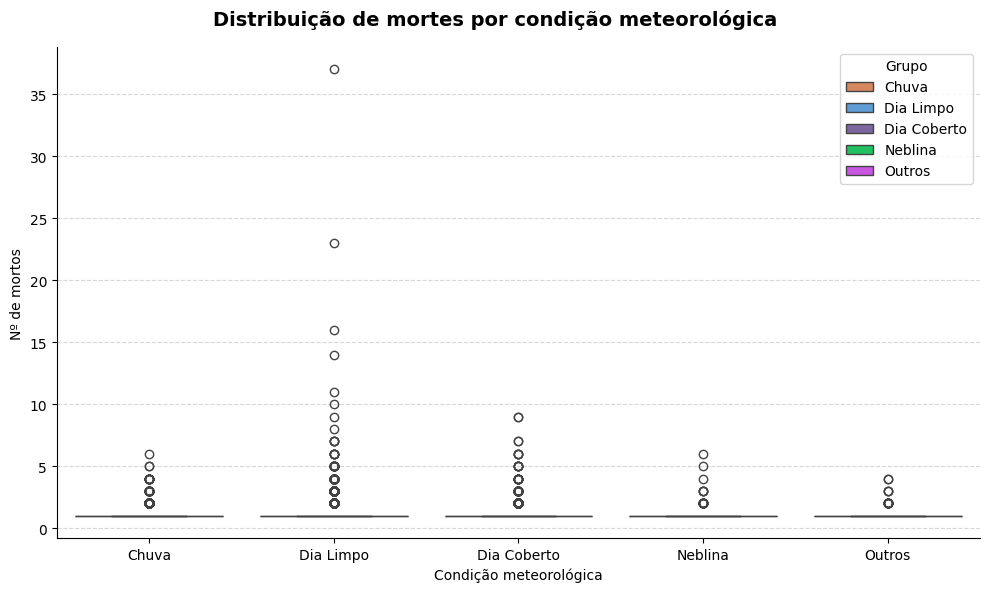

In [22]:
t1_fig1, t1_ax1 = plt.subplots(figsize=(10, 6))
t1_fig1.suptitle(
    "Distribuição de mortes por condição meteorológica",
    fontsize=14, fontweight="bold",
)

sns.boxplot(
    data=df_viz,
    x="grupo",
    y="mortos",
    hue="grupo",
    order=GRUPOS_ORDEM_T1,
    hue_order=GRUPOS_ORDEM_T1,
    palette=PALETTE,
    legend=True,
    ax=t1_ax1,
)

t1_ax1.set_xlabel("Condição meteorológica")
t1_ax1.set_ylabel("Nº de mortos")
# t1_ax1.set_yscale("log")
t1_ax1.legend(title="Grupo", frameon=True, edgecolor="#cccccc")
style_ax(t1_ax1)
t1_fig1.tight_layout()

Porém, analisando a distribuição do número de mortes por condição meteorológica no momento do acidente, providenciado pelo boxplot, temos uma imagem curiosa, que refuta o resultado do teste. Mas, antes de falarmos disso, falemos do outro ponto que chama atenção: Não é comum termos grandes números de mortes em acidentes, com a quase totalidade dos acidentes acarretando na morte de apenas uma pessoa. Todos os outros números são tratados como outliers.

Agora, sobre a divergência entre a imagem e o resultado do teste Anova. Chama atenção que apesar do teste ter mostrado que o fator chuva aumenta o número de fatalidades, na distribuição do boxplot, vemos que dias limpos, com sol e céu claro, são o que concentram os números mais elevados de fatalidades, chegando a ultrapassar mais de 10 mortes em alguns casos. Já as chuvas, apesar de causarem um aumento no número de mortes que supera a condição de neblina, por exemplo, não supera os dias limpos ou encobertos.

Talvez o teste Anova tenha sido utilizado de forma errada para analisar essa hipótese, e uma análise que compara isoladamente cada um dos fatores climáticos se provasse mais acertiva, já que, ao colocarmos todos os fatores climáticos na balança, no fim, a hipótese que estamos testando é: "Fatores climáticos contra Dias limpos".

### T2: Fatores climáticos contribuem mais para o aumento de fatalidades em acidentes do que outros fatores, tais como, época do ano e fins de semana

* H0: Fatores climáticos NÃO são o maior contribuinte para o aumento de acidentes, quando comparados com época do ano e fins de semana.
* H1: Fatores climáticos são o maior contribuinte para o aumento de acidentes, quando comparados com época do ano e fins de semana.

O tempo não é o único fator que pode contribuir para o aumento no número de acidentes, durante feriados, fins de semana, muitas pessoas saem viajar e pegam as rodovias, o que aumenta o fluxo de veículos e a chance de acidentes. Mas, qual fator será que contribuí mais?

Para esse teste, iremos comparar acidentes que ocorreram sob condições climáticas que podem aumentar a chance de ocorrem fatalidades, como Chuva, Neblina e Neve (apesar de no Brasil não ser nenhum um pouco comum), com aqueles que ocorreram em fins de semana, feriados e feriados prolongados.

Como um acidente pode ocorrer sob chuva e em um fim de semana, feriados prolongados automaticamente implicam em considerar o fim de semana também, um mesmo acidente poderá estar em mais de um conjunto.

In [23]:
df_t2 = df_acidentes.copy()

mask_mortos_t2 = df_t2['teve_mortos']
mask_fim_de_semana = (mask_mortos_t2 & df_t2['e_fim_de_semana'])
mask_fatores_climaticos = (mask_mortos_t2 & df_t2['condicao_metereologica'].isin(['Chuva', 'Nevoeiro/Neblina', 'Neve']))
mask_feriados = (mask_mortos_t2 & df_t2['e_feriado'])
mask_feriados_prolongados = (mask_mortos_t2 & df_t2['em_feriado_prolongado'])


In [24]:

df_fim_de_semana = df_t2[mask_fim_de_semana]['mortos']
df_fatores_climaticos = df_t2[mask_fatores_climaticos]['mortos']
df_feriados = df_t2[mask_feriados]['mortos']
df_feriados_prolongados = df_t2[mask_feriados_prolongados]['mortos']

In [25]:
print("Número de acidentes por período:")
print(f"n Total: {len(df_t2[mask_mortos_t2])}")
print(f"n (Fim de semana):  {len(df_fim_de_semana)}")
print(f"n (Fatores climáticos):  {len(df_fatores_climaticos)}")
print(f"n (Feriados):  {len(df_feriados)}")
print(f"n (Feriados prolongados):  {len(df_feriados_prolongados)}")

Número de acidentes por período:
n Total: 15290
n (Fim de semana):  5798
n (Fatores climáticos):  1479
n (Feriados):  487
n (Feriados prolongados):  739


Como estamos comparando várias categorias, novamente será realizado o teste Anova.

In [26]:
stat_t2, p_t2 = f_oneway(df_fatores_climaticos, df_fim_de_semana, df_feriados, df_feriados_prolongados, equal_var=True, nan_policy="raise")
print(f"\n[ANOVA] Estatística F: {stat_t2:.2f}, p-valor: {p_t2:.4f}")


[ANOVA] Estatística F: 1.77, p-valor: 0.1498


Com o resultado do teste, p - 0,1498 > alfa = 0.05, não rejeitamos $H_0$, mostrando que, quando se fala no aumento das fatalidades, fatores climáticos não são o fator que mais contribuí.

In [27]:
GRUPO_T2_MAP = {
    "Fatores climáticos": mask_fatores_climaticos,
    "Fim de semana": mask_fim_de_semana,
    "Feriados": mask_feriados,
    "Feriados prolongados": mask_feriados_prolongados,
}

# Adiciona coluna de grupo ao dataframe filtrado
df_t2["grupo"] = None
for label, mask in GRUPO_T2_MAP.items():
    df_t2.loc[mask, "grupo"] = label

df_viz_t2 = df_t2[df_t2["grupo"].notna()].copy()

# Paleta e ordem fixos para consistência entre gráficos
GRUPOS_ORDEM_T2 = list(GRUPO_T2_MAP.keys())
PALETTE = {
    GRUPOS_ORDEM_T2[0]: "#7B5EA7",   # roxo  → fatores climaticos
    GRUPOS_ORDEM_T2[1]: "#4C9BE8",   # azul  → fim de semana
    GRUPOS_ORDEM_T2[2]: "#E8824C",   # laranja → feriados
    GRUPOS_ORDEM_T2[3]: "#06DA5B",   # verde → feriados prolongados
}



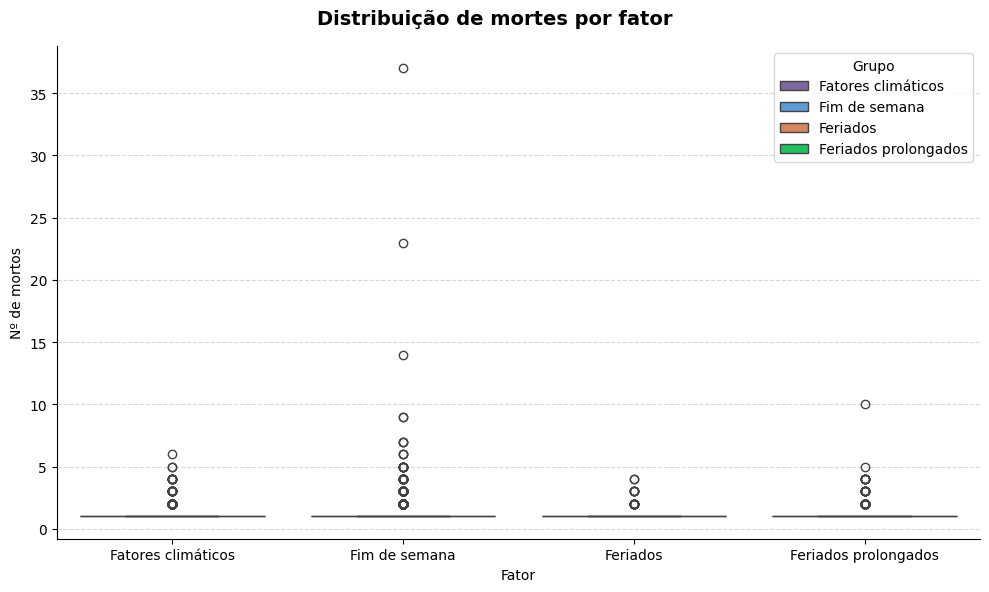

In [28]:
t2_fig1, t2_ax1 = plt.subplots(figsize=(10, 6))
t2_fig1.suptitle(
    "Distribuição de mortes por fator",
    fontsize=14, fontweight="bold",
)

sns.boxplot(
    data=df_viz_t2,
    x="grupo",
    y="mortos",
    hue="grupo",
    order=GRUPOS_ORDEM_T2,
    hue_order=GRUPOS_ORDEM_T2,
    palette=PALETTE,
    legend=True,
    ax=t2_ax1,
)

t2_ax1.set_xlabel("Fator")
t2_ax1.set_ylabel("Nº de mortos")
# t2_ax1.set_yscale("log")
t2_ax1.legend(title="Grupo", frameon=True, edgecolor="#cccccc")
style_ax(t2_ax1)
t2_fig1.tight_layout()

Olhando a distribuição do número de mortes por fator, fornecida pelo Boxplot, percebe-se que novamente o número de fatalidades na maioria dos acidentes não é expressivamente alta, ocorrendo geralmente uma única morte, com os outros valores sendo outliers.

Já quando se fala do fator mais determinante, percebe-se que, apesar de fatores climáticos certamente terem uma influência, os fins de semana são o fator mais determinante, com acidentes ceifando mais de 10, 20, 35 vidas.

A maior surprese, para mim, são os feriados, que possuem a distribuição mais "comportada", com os outliers não superando cinco mortes. Uma hipótese que podemos levantar é que, em um feriado, as pessoas geralmente viajam para aproveitá-lo em algum local, com elas já tendo chegado ao destino nesse dia, com os acidentes ocorrendo durante o deslocamento, que cairá ou num fim de semana, ou num feriado prolongado.

### T3: Feriados, normais e prolongados, contribuem para o aumento da quantidade de fatalidades em acidentes, quando comparados a dias da semana e fins de semana sem feriados

* H0: Feriados, normais e prolongados, NÃO contribuem para o aumento de acidentes na fatalidade do número de acidentes, quando comparados a dias da semana e fins de semana sem feriados
* H1: Feriados, normais e prolongados, contribuinte para o aumento de acidentes na fatalidade do número de acidentes, quando comparados a dias da semana e fins de semana sem feriados


Durante feriados, muitas pessoas pegam a estrada e viajam, o que aumente o fluxo de veículos nas rodovias. Então, é natural supormos que durante esses períodos, a chance de acidentes e o número de fatalidades nas rodovias do país aumente.

Então, para o teste, iremos comparar as seguintes categorias:
* Fim de Semana: Acidentes que ocorreram em fins de semana que não foram feriados prolongados.
* Feriados: Acidentes que ocorreram durante feriados, ou feriados prolongados.
* Dia Comum: Acidentes que não ocorreram em fins de semana, ou feriados, ou feriados prolongados.

In [29]:
df_t3 = df_acidentes.copy()

mask_mortos_t3 = df_t3['teve_mortos']
mask_fim_de_semana_t3 = (mask_mortos_t3 & df_t3['e_fim_de_semana'] & ~df_t3['em_feriado_prolongado'])
mask_feriados_t3 = (mask_mortos_t3 & (df_t3['e_feriado'] | df_t3['em_feriado_prolongado']))
mask_dia_comum_t3 = (mask_mortos_t3 & ~df_t3['e_fim_de_semana'] & ~df_t3['e_feriado'] & ~df_t3['em_feriado_prolongado'])


In [30]:

df_fim_de_semana_t3 = df_t3[mask_fim_de_semana_t3]['mortos']
df_feriados_t3 = df_t3[mask_feriados_t3]['mortos']
df_dia_comum_t3 = df_t3[mask_dia_comum_t3]['mortos']

In [31]:
print("Número de acidentes por período:")
print(f"n Total: {len(df_t3[mask_mortos_t3])}")
print(f"n (Fim de semana):  {len(df_fim_de_semana_t3)}")
print(f"n (Feriados):  {len(df_feriados_t3)}")
print(f"n (Dia comum):  {len(df_dia_comum_t3)}")

Número de acidentes por período:
n Total: 15290
n (Fim de semana):  5368
n (Feriados):  991
n (Dia comum):  9108


Como estamos comparando três categorias distintas, novamente será realizado um teste Anova.

In [32]:
stat_t3, p_t3 = f_oneway(df_feriados_t3, df_dia_comum_t3, df_fim_de_semana_t3, equal_var=True, nan_policy="raise")
print(f"\n[ANOVA] Estatística F: {stat_t3:.2f}, p-valor: {p_t3:.4f}")


[ANOVA] Estatística F: 1.50, p-valor: 0.2223


Pelo valor do teste, p = 0.2223 > alfa = 0.05, não rejeitamos a hipótese $H_0$, então feriados não são o fator que mais contribuem para o aumento no número de fatalidades.

In [33]:
GRUPO_T3_MAP = {
    "Fim de semana": mask_fim_de_semana_t3,
    "Feriados": mask_feriados_t3,
    "Dia comum": mask_dia_comum_t3,
}

# Adiciona coluna de grupo ao dataframe filtrado
df_t3["grupo"] = None
for label, mask in GRUPO_T3_MAP.items():
    df_t3.loc[mask, "grupo"] = label

df_viz_t3 = df_t3[df_t3["grupo"].notna()].copy()

# Paleta e ordem fixos para consistência entre gráficos
GRUPOS_ORDEM_T3 = list(GRUPO_T3_MAP.keys())
PALETTE = {
    GRUPOS_ORDEM_T3[0]: "#4C9BE8",   # azul  → feriados normais e prolongados
    GRUPOS_ORDEM_T3[1]: "#7B5EA7",   # roxo  → Fim de semana sem feriado prolongado
    GRUPOS_ORDEM_T3[2]: "#E8824C",   # laranja → dias comuns
}



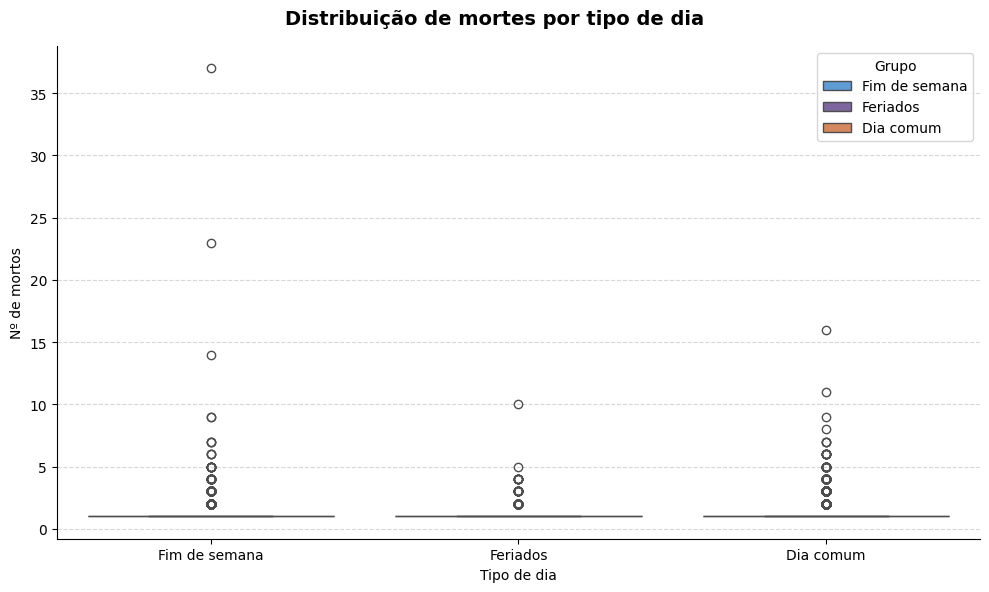

In [34]:
t3_fig1, t3_ax1 = plt.subplots(figsize=(10, 6))
t3_fig1.suptitle(
    "Distribuição de mortes por tipo de dia",
    fontsize=14, fontweight="bold",
)

sns.boxplot(
    data=df_viz_t3,
    x="grupo",
    y="mortos",
    hue="grupo",
    order=GRUPOS_ORDEM_T3,
    hue_order=GRUPOS_ORDEM_T3,
    palette=PALETTE,
    legend=True,
    ax=t3_ax1,
)

t3_ax1.set_xlabel("Tipo de dia")
t3_ax1.set_ylabel("Nº de mortos")
# t3_ax1.set_yscale("log")
t3_ax1.legend(title="Grupo", frameon=True, edgecolor="#cccccc")
style_ax(t3_ax1)
t3_fig1.tight_layout()

Pela distribuição do boxplot, percebemos que os fins de semana, sem feriados prolongados, são o fator que mais teve acidentes com causalidades, superando em muito, os feriados, que ficam atrás até dos dias comuns.

## Insights para a etapa 4

Analisando como os diferentes fatores afetam o número de mortes nos acidentes, percebe-se que considerar a variável `e_fim_de_semana` pode ajudar em muito a classificação correta da fatalidade no acidente, já que, nos três testes, esse é o fator que mais se destaca, em relação a todos os outros.

# Etapa 4

## Teste baseline com dropna

Para testar o desempenho do dataset sem nenhum pré-processamento mais intensivo e integração com fontes externas, será criado um baseline com dropna.

In [35]:
for c in df_acidentes.columns.tolist():
    print(df_acidentes[c].isna().sum(), c)

0 id
0 data_inversa
0 dia_semana
0 horario
0 uf
0 br
0 km
0 municipio
0 causa_acidente
0 tipo_acidente
3 classificacao_acidente
0 fase_dia
0 sentido_via
0 condicao_metereologica
0 tipo_pista
0 tracado_via
0 uso_solo
0 pessoas
0 mortos
0 feridos_leves
0 feridos_graves
0 ilesos
0 ignorados
0 feridos
0 veiculos
0 latitude
0 longitude
22 regional
90 delegacia
196 uop
0 teve_mortos
0 teve_feridos_leves
0 teve_feridos_graves
0 teve_ilesos
0 teve_feridos
0 teve_ignorados
0 e_fim_de_semana
0 e_feriado
0 em_feriado_prolongado
0 estacao_mais_proxima
0 precimitacao_momento


In [36]:
def split_data_in_folds(data, k_folds=5, random_state=42):
    """Divide os dados em k folds para validação cruzada."""
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

    (X, y) = data

    folds = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        folds.append((X_train, y_train, X_test, y_test))

    return folds


In [37]:
KNN_K_ARRAY = [1, 3, 5, 7, 9]
KNN_DISTANCE_METRICS = ["euclidean", "manhattan", "minkowski"]
KNN_LABEL = "knn"
KNN_PARAMETERS = {"knn__n_neighbors": KNN_K_ARRAY, "knn__metric": KNN_DISTANCE_METRICS}

RF_N_ESTIMATORS = [100, 200]  # [100, 150, 200, 400]
RF_MIN_SAMPLES_LEAFS = [3, 10, 15, 30]
RF_MIN_SAMPLES_SPLITS = [2, 4, 16, 40]
RF_MAX_DEPTHS = [None, 3, 8]  # [None, 2, 3, 4, 5, 8, 12]
RF_MAX_FEATURES = ["sqrt"]  # ["sqrt", "log2", 0, 2, 0.5, None]
RF_MAX_SAMPLES = [None]  # [None, 0.6, 0.8]
RF_CRITERIONS = ["gini", "entropy"]
RF_CLASS_WEIGHT = [None, "balanced_subsample"]  # [None, "balanced_subsample"]
RF_LABEL = "rf"
RF_PARAMETERS = {
    "rf__n_estimators": RF_N_ESTIMATORS,
    "rf__min_samples_leaf": RF_MIN_SAMPLES_LEAFS,
    "rf__min_samples_split": RF_MIN_SAMPLES_SPLITS,
    "rf__max_depth": RF_MAX_DEPTHS,
    "rf__max_features": RF_MAX_FEATURES,
    "rf__max_samples": RF_MAX_SAMPLES,
    "rf__criterion": RF_CRITERIONS,
    "rf__class_weight": RF_CLASS_WEIGHT,
}

SVM_KERNELS = ["rbf"]
SVM_C = [0.1, 1, 10, 100, 1000]
SVM_GAMMA = [2e-5, 2e-3, 2e-1, "auto", "scale"]
SVM_LABEL = "svm"
SVM_PARAMETERS = {
    "svm__kernel": SVM_KERNELS,
    "svm__C": SVM_C,
    "svm__gamma": SVM_GAMMA,
}


def tune_classifier(classifier, classifier_label, parameters, preprocessor):

    pipe = Pipeline(
        [
            ("preprocess", preprocessor),
            (classifier_label, classifier),
        ]
    )

    tuned_model = GridSearchCV(pipe, parameters, n_jobs=-1)

    return tuned_model

In [38]:
from typing import TypedDict, TypeAlias, Literal

class MetricBreakdown(TypedDict):
    macro: float
    weighted: float
    samples: list[float]

class FoldMetrics(TypedDict):
    accuracy: float
    f1: MetricBreakdown
    precision: MetricBreakdown
    recall: MetricBreakdown
    confusion_matrix: list[list[int]]

class AggregatedMetrics(TypedDict):
    accuracy: float
    f1: MetricBreakdown
    precision: MetricBreakdown
    recall: MetricBreakdown

ClassifierGeneralMetrics: TypeAlias = tuple[
    float,
    MetricBreakdown,
    MetricBreakdown,
    MetricBreakdown,
]

class ModelRunResult(TypedDict):
    folds: list[FoldMetrics]
    accuracy: float
    f1: MetricBreakdown
    precision: MetricBreakdown
    recall: MetricBreakdown

class ClassificationResults(TypedDict):
    knn: ModelRunResult
    random_forest: ModelRunResult
    svm: ModelRunResult

class DropnaRunSummary(TypedDict):
    key: str
    strategy: Literal["dropna"]
    variant: str
    rows_original: int
    rows_after_prepros: int
    results: ClassificationResults

class DropnaRunError(TypedDict):
    key: str
    error: str

In [39]:
def build_preprocessor_baseline(
    X: pd.DataFrame, scale_numeric: bool
) -> ColumnTransformer:
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [column for column in X.columns if column not in numeric_cols]
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler() if scale_numeric else "passthrough", numeric_cols),
            ("cat", make_one_hot_encoder(), categorical_cols),
        ],
        remainder="drop",
    )


def compute_classifier_general_metrics(
    fold_metrics: list[FoldMetrics],
    k_folds: int,
) -> ClassifierGeneralMetrics:
    """
    Computa a média das métricas de classificação (accuracy, f1, precision, recall) a partir dos resultados de cada fold.
    """

    accuracy_sum = 0

    f1_sum = {
        "macro": 0,
        "weighted": 0,
        "samples": [0, 0],
    }
    precision_sum = {
        "macro": 0,
        "weighted": 0,
        "samples": [0, 0],
    }
    recall_sum = {
        "macro": 0,
        "weighted": 0,
        "samples": [0, 0],
    }
    for fold_metric in fold_metrics:
        accuracy_sum += fold_metric["accuracy"]

        f1_sum["macro"] += fold_metric["f1"]["macro"]
        f1_sum["weighted"] += fold_metric["f1"]["weighted"]
        f1_sum["samples"][0] += fold_metric["f1"]["samples"][0]
        f1_sum["samples"][1] += fold_metric["f1"]["samples"][1]

        precision_sum["macro"] += fold_metric["precision"]["macro"]
        precision_sum["weighted"] += fold_metric["precision"]["weighted"]
        precision_sum["samples"][0] += fold_metric["precision"]["samples"][0]
        precision_sum["samples"][1] += fold_metric["precision"]["samples"][1]

        recall_sum["macro"] += fold_metric["recall"]["macro"]
        recall_sum["weighted"] += fold_metric["recall"]["weighted"]
        recall_sum["samples"][0] += fold_metric["recall"]["samples"][0]
        recall_sum["samples"][1] += fold_metric["recall"]["samples"][1]

    accuracy = accuracy_sum / k_folds
    f1 = {
        "macro": f1_sum["macro"] / k_folds,
        "weighted": f1_sum["weighted"] / k_folds,
        "samples": [f1_sum["samples"][0] / k_folds, f1_sum["samples"][1] / k_folds],
    }
    precision = {
        "macro": precision_sum["macro"] / k_folds,
        "weighted": precision_sum["weighted"] / k_folds,
        "samples": [
            precision_sum["samples"][0] / k_folds,
            precision_sum["samples"][1] / k_folds,
        ],
    }
    recall = {
        "macro": recall_sum["macro"] / k_folds,
        "weighted": recall_sum["weighted"] / k_folds,
        "samples": [
            recall_sum["samples"][0] / k_folds,
            recall_sum["samples"][1] / k_folds,
        ],
    }

    return accuracy, f1, precision, recall


def run_classification_baseline(
    X: pd.DataFrame,
    y: pd.Series,
    k_folds: int,
    random_state: int,
) -> ClassificationResults:

    folds = split_data_in_folds((X, y), k_folds=k_folds, random_state=random_state)

    results = {
        "knn": {"folds": []},
        "random_forest": {"folds": []},
        "svm": {"folds": []},
    }

    for fold_index, (X_train, y_train, X_test, y_test) in enumerate(folds):
        models = {
            "knn": tune_classifier(
                KNeighborsClassifier(),
                KNN_LABEL,
                KNN_PARAMETERS,
                build_preprocessor_baseline(X_train, scale_numeric=True),
            ),
            "random_forest": tune_classifier(
                RandomForestClassifier(random_state=random_state),
                RF_LABEL,
                RF_PARAMETERS,
                build_preprocessor_baseline(X_train, scale_numeric=False),
            ),
            "svm": tune_classifier(
                SVC(random_state=random_state),
                SVM_LABEL,
                SVM_PARAMETERS,
                build_preprocessor_baseline(X_train, scale_numeric=True),
            ),
        }

        for name, model in models.items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            accuracy = float(accuracy_score(y_test, pred))
            macro_f1 = float(f1_score(y_test, pred, average="macro"))
            macro_precision = float(precision_score(y_test, pred, average="macro"))
            macro_recall = float(recall_score(y_test, pred, average="macro"))
            weighted_f1 = float(f1_score(y_test, pred, average="weighted"))
            weighted_precision = float(
                precision_score(y_test, pred, average="weighted")
            )
            weighted_recall = float(recall_score(y_test, pred, average="weighted"))
            sampled_f1 = [float(f1) for f1 in f1_score(y_test, pred, average="samples")]
            sampled_precision = [
                float(precision)
                for precision in precision_score(y_test, pred, average="samples")
            ]
            sampled_recall = [
                float(recall)
                for recall in recall_score(y_test, pred, average="samples")
            ]

            confusion_matrix_data = confusion_matrix(y_test, pred)

            # Computa todas as métricas da fold
            metrics = {
                "accuracy": accuracy,
                "f1": {
                    "macro": macro_f1,
                    "weighted": weighted_f1,
                    "samples": sampled_f1,
                },
                "precision": {
                    "macro": macro_precision,
                    "weighted": weighted_precision,
                    "samples": sampled_precision,
                },
                "recall": {
                    "macro": macro_recall,
                    "weighted": weighted_recall,
                    "samples": sampled_recall,
                },
                "confusion_matrix": confusion_matrix_data.tolist(),
            }
            results[name]["folds"].append(metrics)

            print(f"\n[model] {name} | Fold {fold_index}")
            print(metrics)
            print("Matriz de confusao:")
            print(confusion_matrix_data)
            print(classification_report(y_test, pred))

    for name, model_result in results.items():
        fold_metrics = model_result["folds"]
        accuracy, f1, precision, recall = compute_classifier_general_metrics(
            fold_metrics, k_folds
        )
        results[name]["accuracy"] = accuracy
        results[name]["f1"] = f1
        results[name]["precision"] = precision
        results[name]["recall"] = recall

    return results


def run_one_dataset_with_drop(
    data: pd.DataFrame,
    key: str,
    target,
    out_dir: str = "data",
    k_folds: float = 5,
    random_state: int = 42,
) -> DropnaRunSummary:
    data_dir = Path(out_dir)
    df = data.copy()

    print("\n" + "=" * 80)
    print(f"Dataset: {key} | Target: {target}")
    print("=" * 80)
    print("Shape original:", df.shape)

    df = normalize_missing_values(df)

    rows_before = len(df)
    df_clean = df.dropna(axis=0, how="any").copy()
    rows_after = len(df_clean)

    rows_dropped = rows_before - rows_after

    print(
        "Linhas removidas no dropna:",
        rows_dropped,
        f"({(rows_dropped / rows_before):.2%})",
    )

    if rows_after == 0:
        raise RuntimeError("Dataset vazio apos dropna.")

    ignored_columns = [
        "mortos",
        "delegacia",
        "uop",
        "teve_mortos",
        "teve_feridos_leves",
        "teve_feridos_graves",
        "teve_ilesos",
        "teve_feridos",
        "teve_ignorados",
        "feridos",
        "feridos_leves",
        "feridos_graves",
        "ilesos",
        "e_feriado",
        "em_feriado_prolongado",
        "e_fim_de_semana",
    ]

    X, y = split_X_y(df_clean, target, ignored_columns)

    print("Distribuicao da target:")
    print(y.value_counts())
    results = run_classification_baseline(
        X, y, k_folds=k_folds, random_state=random_state
    )

    result_dir = data_dir / "results" / "baseline"
    result_dir.mkdir(parents=True, exist_ok=True)
    out_path = result_dir / f"{key}_baseline_results.json"
    out_path.write_text(
        json.dumps(
            {
                "key": key,
                "target": target,
                "variant": "default",
                "shape_original": list(df.shape),
                "shape_after_prepro": list(df_clean.shape),
                "test_size": k_folds,
                "random_state": random_state,
                "results": results,
            },
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )
    print("Resultados salvos em:", out_path)

    return {
        "key": key,
        "strategy": "dropna",
        "variant": "default",
        "rows_original": int(df.shape[0]),
        "rows_after_prepros": int(df_clean.shape[0]),
        "results": results,
    }

In [40]:
DATASET = "dataset_final"
TARGET = "teve_mortos"
OUT_DIR = "data"
K_FOLDS = 5
RANDOM_STATE = 42

In [ ]:
print(f"{'=' * 5} DROPNA {'=' * 5}")


all_runs: list[DropnaRunSummary] = []
try:
    run_info = run_one_dataset_with_drop(
        data=df_acidentes,
        key=DATASET,
        target=TARGET,
        out_dir=OUT_DIR,
        k_folds=K_FOLDS,
        random_state=RANDOM_STATE,
    )
    all_runs.append(run_info)
except Exception as e:
    print(f"\n[ERRO] key={DATASET}: {e}")
    all_runs.append({"key": DATASET, "error": str(e)})


# --- Monta tabelas separadas por tipo de tarefa ---

classification_rows = []
regression_rows = []

for r in all_runs:
    base = {"experiment": "dropna", "key": r["key"], "variant": r.get("variant", "default"), "best_model": "", "error": r.get("error", "")}

    if "error" in r and "results" not in r:
        classification_rows.append({**base, "accuracy": None, "macro_f1": None, "weighted_f1": None, "weighted_precision": None, "weighted_recall": None})
        continue

    best = max(r["results"], key=lambda m: r["results"][m]["f1"]["macro"] )
    m = r["results"][best]
    classification_rows.append({
        "experiment": "dropna",
        "key": r["key"],
        "variant": r["variant"],
        "best_model": best,
        "accuracy": round(m["accuracy"], 4),
        "macro_f1": round(m["f1"]["macro"], 4),
        "macro_precision": round(m["precision"]["macro"], 4),
        "macro_recall": round(m["recall"]["macro"], 4),
        "weighted_f1": round(m["f1"]["weighted"], 4),
        "weighted_precision": round(m["precision"]["weighted"], 4),
        "weighted_recall": round(m["recall"]["weighted"], 4),
        "error": "",
        "nao_teve_mortes_f1": round(m["f1"]["samples"][0], 4),
        "nao_teve_mortes_precision": round(m["precision"]["samples"][0], 4),
        "nao_teve_mortes_recall": round(m["recall"]["samples"][0], 4),
        "teve_mortes_f1": round(m["f1"]["samples"][1], 4),
        "teve_mortes_precision": round(m["precision"]["samples"][1], 4),
        "teve_mortes_recall": round(m["recall"]["samples"][1], 4),
    })

# Exibe  resultados e salva CSVs 


data_path = Path(OUT_DIR)

if classification_rows:
    clf_df = pd.DataFrame(classification_rows, columns=["experiment", "key", "variant", "best_model", "accuracy", "macro_f1", "weighted_f1", "weighted_precision", "weighted_recall", "error"] )
    print("\n=== Classificacao ===")
    display(clf_df)
    clf_path = data_path / "classification_summary.csv"
    clf_df.to_csv(clf_path, index=False)
    print("Salvo em:", clf_path)


print(f"{'=' * 5} FIM DROPNA {'=' * 5}")

===== DROPNA =====

Dataset: dataset_final | Target: teve_mortos
Shape original: (213451, 41)
Linhas removidas no dropna: 199 (0.09%)
Distribuicao da target:
teve_mortos
False    197974
True      15278
Name: count, dtype: int64
